In [ ]:
#uploading my 3 files
import pandas as pd

# Load the Excel files
sales = pd.read_excel("/content/sales data.xlsx")
products = pd.read_excel("/content/product data.xlsx")
customers = pd.read_excel("/content/customer data.xlsx")


In [ ]:
#printing first 5 rows of each data
print(sales.head())


   Row ID        Order ID  Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156       42682      42685    Second Class    CG-12520   
1       2  CA-2016-152156       42682      42685    Second Class    CG-12520   
2       3  CA-2016-138688       42533      42537    Second Class    DV-13045   
3       4  US-2015-108966       42288      42295  Standard Class    SO-20335   
4       5  US-2015-108966       42288      42295  Standard Class    SO-20335   

        Product ID     Sales  Quantity  Discount    Profit  
0  FUR-BO-10001798  261.9600         2      0.00   41.9136  
1  FUR-CH-10000454  731.9400         3      0.00  219.5820  
2  OFF-LA-10000240   14.6200         2      0.00    6.8714  
3  FUR-TA-10000577  957.5775         5      0.45 -383.0310  
4  OFF-ST-10000760   22.3680         2      0.20    2.5164  


In [ ]:
print(products.head())



        Product ID         Category Sub-Category  \
0  FUR-BO-10001798        Furniture    Bookcases   
1  FUR-CH-10000454        Furniture       Chairs   
2  OFF-LA-10000240  Office Supplies       Labels   
3  FUR-TA-10000577        Furniture       Tables   
4  OFF-ST-10000760  Office Supplies      Storage   

                                        Product Name  
0                  Bush Somerset Collection Bookcase  
1  Hon Deluxe Fabric Upholstered Stacking Chairs,...  
2  Self-Adhesive Address Labels for Typewriters b...  
3      Bretford CR4500 Series Slim Rectangular Table  
4                     Eldon Fold 'N Roll Cart System  


In [ ]:
print(customers.head())

  Customer ID    Customer Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    CG-12520      Claire Gute   Consumer  United States        Henderson   
2    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
3    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   

        State  Postal Code Region  
0    Kentucky        42420  South  
1    Kentucky        42420  South  
2  California        90036   West  
3     Florida        33311  South  
4     Florida        33311  South  


In [ ]:
#dropping duplicate rows from product and customer dataset
#we are not  dropping duplicate rows from sales because each row represent a specific real transaction

products = products.drop_duplicates(subset=['Product ID'])


customers = customers.drop_duplicates(subset=['Customer ID'])


In [ ]:
#merging the dataset
# Merge Sales with Products
sales_products = pd.merge(sales, products, on="Product ID", how="left")

# Merge the above with Customers
full_data = pd.merge(sales_products, customers, on="Customer ID", how="left")


**Creating new calculated columns**

***TOTAL REVENUE***

In [ ]:
full_data["total_revenue"] = full_data["Quantity"] * full_data["Sales"]

***PROFIT MARGIN***

In [ ]:
full_data["profit_margin"] = full_data["Profit"] / full_data["Sales"]

***CUSTOMER LIFETIME VALUE (CLV)***

In [ ]:
full_data["clv"] = full_data.groupby("Customer ID")["total_revenue"].transform('sum')

***DISCOUNT AMOUNT***

In [ ]:
full_data["discount_amount"] = full_data["Sales"] * full_data["Discount"]


***NET REVENUE / REVENUE AFTER DISCOUNT***

In [ ]:
full_data["net_revenue"] = full_data["Sales"] - full_data["discount_amount"]


**FINAL RESULT**

In [ ]:
full_data.head()  # Displays first 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,...,Country,City,State,Postal Code,Region,total_revenue,profit_margin,clv,discount_amount,net_revenue
0,1,CA-2016-152156,42682,42685,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,...,United States,Henderson,Kentucky,42420,South,523.9200,0.1600,2719.7400,0.000000,261.960000
1,2,CA-2016-152156,42682,42685,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,...,United States,Henderson,Kentucky,42420,South,2195.8200,0.3000,2719.7400,0.000000,731.940000
2,3,CA-2016-138688,42533,42537,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,...,United States,Los Angeles,California,90036,West,29.2400,0.4700,29.2400,0.000000,14.620000
3,4,US-2015-108966,42288,42295,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,...,United States,Fort Lauderdale,Florida,33311,South,4787.8875,-0.4000,4832.6235,430.909875,526.667625
4,5,US-2015-108966,42288,42295,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,0.20,...,United States,Fort Lauderdale,Florida,33311,South,44.7360,0.1125,4832.6235,4.473600,17.894400


**GRAPHS**

*Total Revenue by Category*

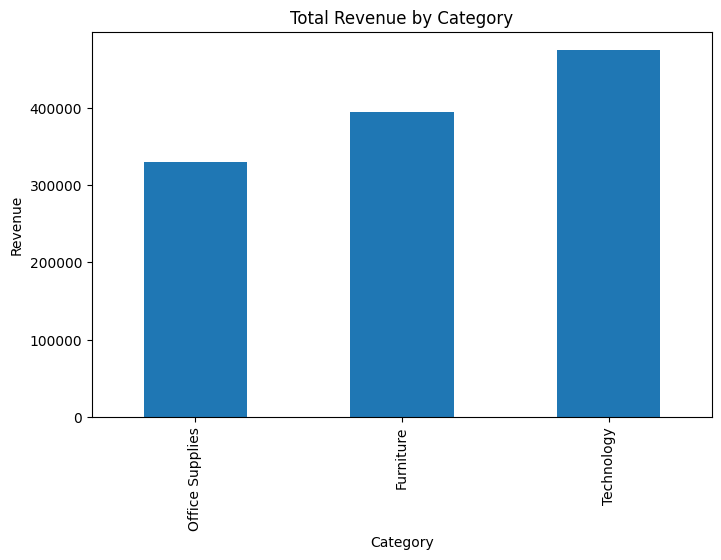

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

category_revenue = full_data.groupby("Category")["total_revenue"].sum().sort_values()
category_revenue.plot(kind="bar", figsize=(8,5), title="Total Revenue by Category")
plt.ylabel("Revenue")
plt.show()


*Top 10 Customers by CLV*

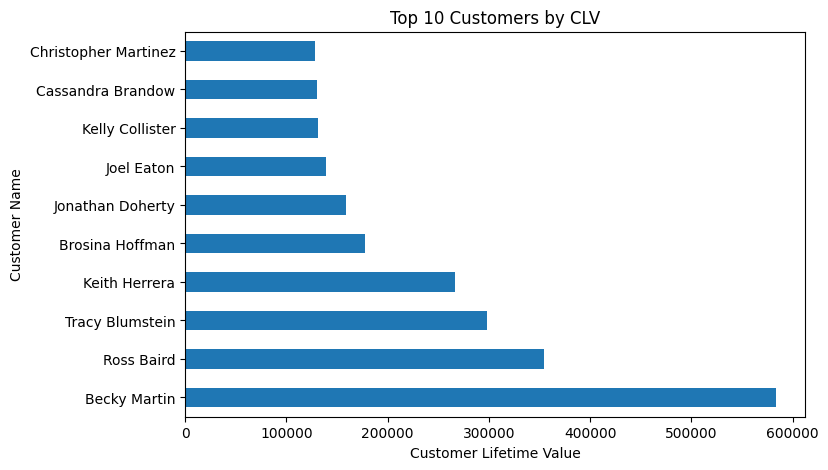

In [ ]:
top_customers = full_data.groupby("Customer Name")["clv"].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind="barh", figsize=(8,5), title="Top 10 Customers by CLV")
plt.xlabel("Customer Lifetime Value")
plt.show()


*Top 10 Products by Total Sales*

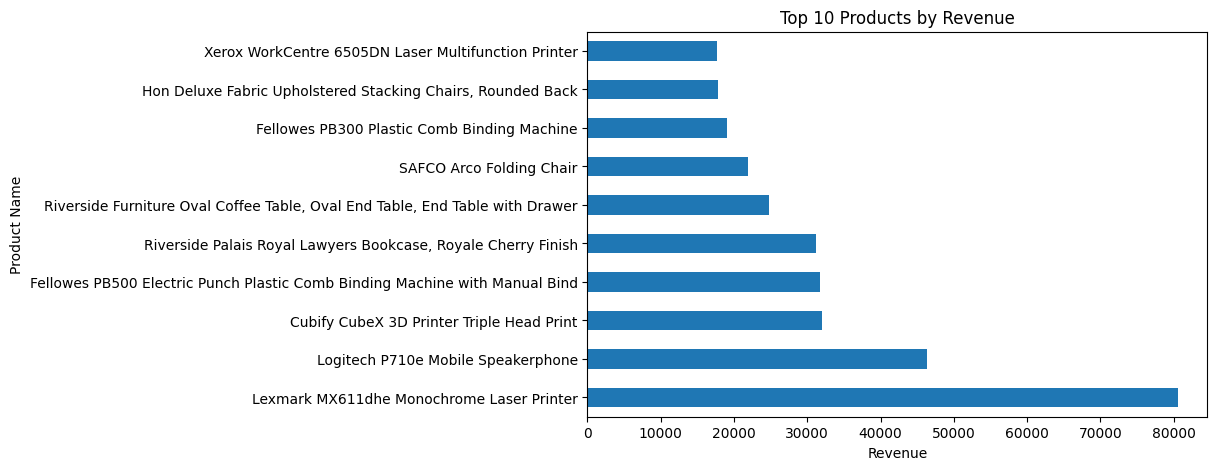

In [ ]:
top_products = full_data.groupby("Product Name")["total_revenue"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="barh", figsize=(8,5), title="Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.show()


*Monthly Revenue Trend*

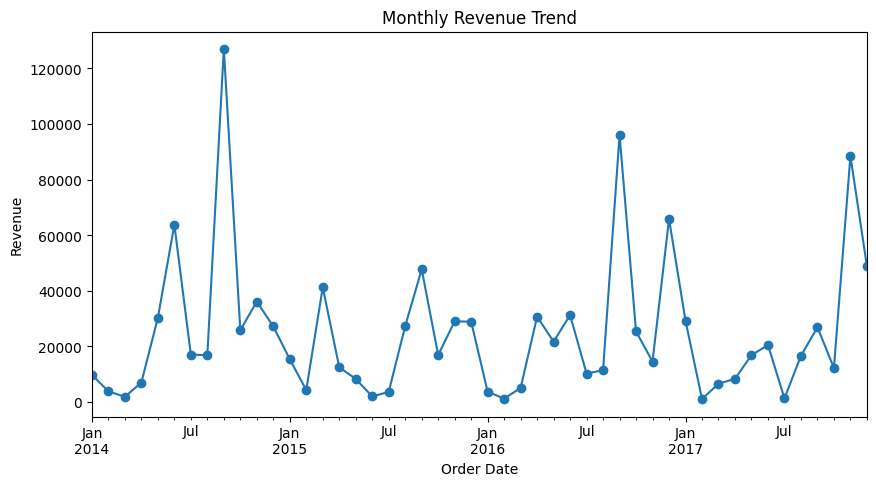

In [ ]:
full_data['Order Date'] = pd.to_datetime(full_data['Order Date'], unit='D', origin='1899-12-30')
monthly_revenue = full_data.groupby(full_data["Order Date"].dt.to_period("M"))["total_revenue"].sum()
monthly_revenue.plot(figsize=(10,5), marker='o', title="Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()